In [6]:
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
sns.set(font_scale=2)

# Multidimensional Intervals with Nuisance Parameters

## 1. Using Likelihood Profiling to Construct Confidence Intervals

**(Review of Seminar 2)**  
Wald’s theorem describes the asymptotic distribution of the estimator:
$$
I(\theta)\,(\hat\theta - \theta)^2 \;\xrightarrow{d}\; \mathcal{N}^2(0,1) \sim \chi^2_1.
$$

for the multidimensional case:

$$
(\hat{\theta}-\theta)^\top I(\theta)\,(\hat{\theta}-\theta)\;\xrightarrow{d}\;\chi^2_{d}.
$$

Independently, Wilks’ theorem describes the asymptotic distribution of the likelihood ratio statistic:
$$
2 \log \frac{L(\hat\theta)}{L(\theta)} \;\xrightarrow{d}\; \chi^2_{\mathrm{dim}(\theta)}.
$$

These two results become numerically close near the MLE because the log-likelihood is locally quadratic.


### What Happens When Nuisance Parameters Are Present

Consider the normal distribution $\mathcal{N}(x \mid \mu, \sigma^2)$.

If we want to profile the likelihood only with respect to the variance, we need to eliminate the mean as follows:

$$
\mathcal{L}_{\max}(\sigma^2) = \max_{\mu} \mathcal{L}(\mu, \sigma^2).
$$

For the normal distribution this can be computed analytically:

$$
\mathcal{L}_{\max}(\sigma^2)
= -\frac{n}{2}\,\log \sigma^2
  - \frac{1}{2\sigma^2} \sum_{i} (x_i - \bar{x})^2.
$$

**Q1: What is the problem with this profile likelihood?**

1) It has a singularity at zero.  
2) Its expectation is not equal to zero.  
3) The equation “derivative of the likelihood equals zero’’ is not solvable for $\sigma^2$ (no optimum).  
4) The optimum is a biased estimator.

Indeed,

$$
\frac{\partial}{\partial \sigma^2} \mathcal{L}_{\max}(\sigma^2)
= -\frac{n}{2\sigma^2}
  + \frac{\sum_{i}(x_i - \bar{x})^2}{2\sigma^4},
$$

and

$$
\mathbb{E}\!\left[
\frac{\partial}{\partial \sigma^2} \mathcal{L}_{\max}(\sigma^2)
\right]
= -\frac{1}{2\sigma^2} \neq 0.
$$

## 1.1 Direct Use of Profiling

Consider a problem where we have $N$ Gaussian distributions $\mathcal{N}(\mu_i, \sigma^2)$, and for each distribution we observe two measurements: $\{x_{i1}, x_{i2}\}_{i=1}^{N}$.

Let us write down the likelihood for this model.


The joint likelihood of all observations is
$$
\mathcal{L}(\{\mu_i\}_{i=1}^N, \sigma^2)
= \prod_{i=1}^N \prod_{j=1}^2
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(
-\frac{(x_{ij} - \mu_i)^2}{2\sigma^2}
\right).
$$

The corresponding log-likelihood is
$$
\ell(\{\mu_i\}_{i=1}^N, \sigma^2)
= -N \log 2\pi\sigma^2
  - \frac{1}{2\sigma^2}
    \sum_{i=1}^N \sum_{j=1}^2 (x_{ij} - \mu_i)^2.
$$

In [7]:
mu = np.array([
    0.88, 2.51, 1.74, -6.74, 1.42, -3.34, -2.72, 6.89, 0.67, -4.18, 8.43, 
    0.15, 3.89, 4.52, -4.05, -6.95, -2.61, -6.52, -6.06, 0.92
])
sigma = 1.

X = np.array([
    [-0.31, 3.2, 1.7, -6.67, 3.12, -3.15, -2.11, 6.88, 0.81, -4.25, 8.58, 1.88, 5.18, 3.81, -4.68, -6.58, -2.16, -7.99, -6.48, 0.89],
    [-0.51, 3.57, 2.81, -5.37, 3.74, -3.27, -3.1, 6.53, -2.7, -3.64, 7.08, -1.15, 4.31, 5.86, -4.55, -7.52, -1.13, -7.53, -6.13, 1.33]
])

In [8]:
X.shape[1]

20

In [9]:
sigmas = np.linspace(0.3, 1.4, 1000)
true_likelihood_profiling = [-X.shape[1] * np.log(_sigma**2) -((X - mu)**2).sum() / (2 * _sigma**2) for _sigma in sigmas]
true_likelihood_profiling = np.array(true_likelihood_profiling)

In [10]:
approximate_likelihood_profiling = [-X.shape[1] * np.log(_sigma**2) -((X - X.mean(axis=0))**2).sum() / (2 * _sigma**2) for _sigma in sigmas]
approximate_likelihood_profiling = np.array(approximate_likelihood_profiling)

**Q2: How many degrees of freedom do I need to substitute into the chi2 distribution?**

1) 1

2) 2

3) 3

4) 4

In [11]:
from scipy.stats import chi2
alpha = 0.1
cut_level = chi2.ppf(q=1 - alpha, df=1) / 2

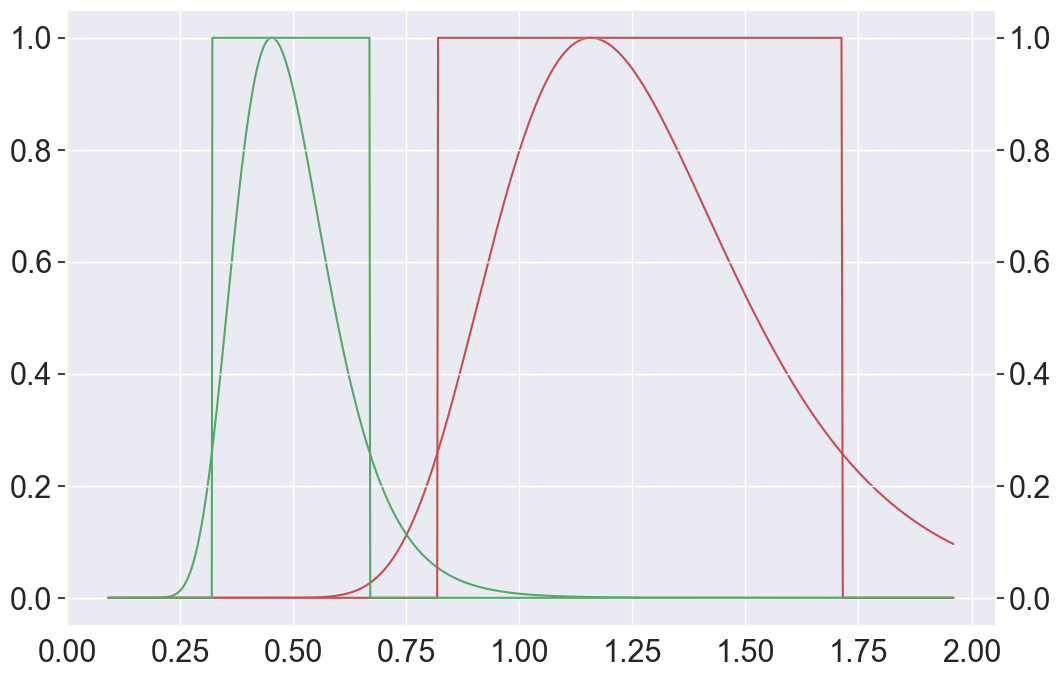

In [12]:
plt.figure(figsize=(12, 8))
plt.plot(sigmas**2, np.exp(true_likelihood_profiling) / np.exp(true_likelihood_profiling).max(), c='r')
plt.plot(sigmas**2, np.exp(approximate_likelihood_profiling) / np.exp(approximate_likelihood_profiling).max(), c="g")

plt.twinx()
plt.plot(
    sigmas**2, 
    true_likelihood_profiling - true_likelihood_profiling.max() > -cut_level, 
    c='r', label='{} confidence interval for sigma^2'.format(1 - alpha)
)

plt.plot(
    sigmas**2, 
    approximate_likelihood_profiling - approximate_likelihood_profiling.max() > -cut_level, 
    c='g', label='{} confidence interval for sigma^2'.format(1 - alpha)
)

plt.show()

**What happened here?**

We have
$$
RSS = \sum_{i=1}^{N} \sum_{j=1}^{2} (x_{ij} - \bar{x}_i)^2 \sim \sigma^2 \chi^2_{N}
$$

and
$$
\hat{\sigma}^2 = \frac{RSS}{2N},
$$

so
$$
\mathbb{E}[\hat{\sigma}^2] = \frac{\sigma^2}{2}.
$$

## 1.2 Splitting the Likelihood into Components

**In more serious literature this is called constructing marginal and conditional likelihoods, but we won’t go into the details here.**

$$
L(\mu, \sigma^2) = L_1(\sigma^2)\, L_2(\mu, \sigma^2)
$$

Such a factorization is not unique. Ideally, we want $L_2$ to be independent of the parameter of interest, or at least **depend on it only weakly**.

**Let us return to our problem with N normal distributions**

Make the following change of variables:

$$
v_i = \frac{x_{i1} - x_{i2}}{\sqrt{2}}
$$

$$
w_i = \frac{x_{i1} + x_{i2}}{\sqrt{2}}
$$

With this transformation, the likelihood factorizes into two independent parts:

$$
p(v_i) = \mathcal{N}(v_i \mid 0, \sigma^2) = L_1(\sigma^2)
$$

$$
p(w_i) = \mathcal{N}(w_i \mid \sqrt{2}\,\mu_i, \sigma^2) = L_2(\mu, \sigma^2)
$$

In [13]:
approximate_marginal_likelihood_profiling = [
    -X.shape[1] * np.log(_sigma**2) / 2 - ((np.diff(X, axis=0) / np.sqrt(2))**2).sum() / (2 * _sigma**2) 
    for _sigma in sigmas
]
approximate_marginal_likelihood_profiling = np.array(approximate_marginal_likelihood_profiling)

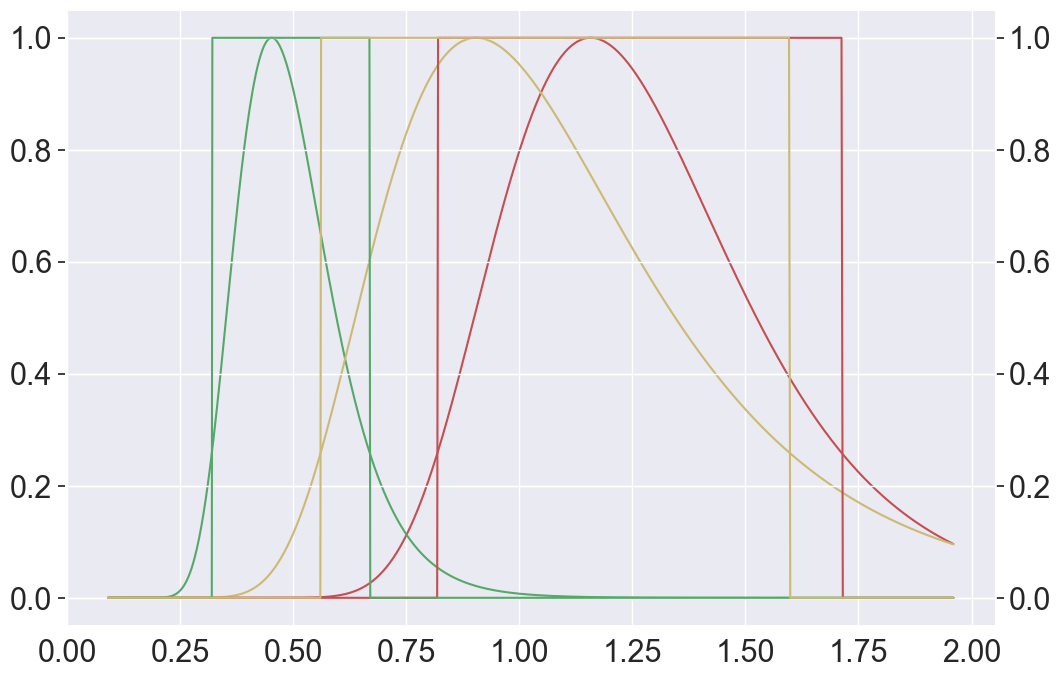

In [14]:
plt.figure(figsize=(12, 8))
plt.plot(
    sigmas**2, 
    np.exp(true_likelihood_profiling) / np.exp(true_likelihood_profiling).max(), c="r"
)
plt.plot(
    sigmas**2, 
    np.exp(approximate_likelihood_profiling) / np.exp(approximate_likelihood_profiling).max(), c="g"
)
plt.plot(
    sigmas**2, 
    np.exp(approximate_marginal_likelihood_profiling) / np.exp(approximate_marginal_likelihood_profiling).max(), c="y"
)

plt.twinx()
plt.plot(
    sigmas**2, 
    true_likelihood_profiling - true_likelihood_profiling.max() > -cut_level, 
    c='r', label='{} confidence interval for sigma^2'.format(1 - alpha)
)

plt.plot(
    sigmas**2, 
    approximate_likelihood_profiling - approximate_likelihood_profiling.max() > -cut_level, 
    c='g', label='{} confidence interval for sigma^2'.format(1 - alpha)
)

plt.plot(
    sigmas**2, 
    approximate_marginal_likelihood_profiling - approximate_marginal_likelihood_profiling.max() > -cut_level, 
    c='y', label='{} confidence interval for sigma^2'.format(1 - alpha)
)
# plt.legend()
plt.show()

#### How can we tell that the marginal likelihood gives better quality?

**1. Estimator bias**

The profile likelihood gave us a biased estimator: $\mathrm{E}\,\hat\sigma^2 = \frac{\sigma^2}{2}$, which is very bad.

The marginal likelihood gives us an unbiased estimator for the variance: $\mathrm{E}\,\hat\sigma^2 = \sigma^2$ — which is better.

**2. How much information we lose**

**For the original model:**

$$I(\sigma^2) = \frac{N}{\sigma^4}$$


**For the marginal likelihood:**

$$I(\sigma^2) = \frac{N}{2\sigma^4}$$

That is, we lose about $50\%$ of the information.

**3. Compute coverage using a toy example**


# 2. Pivoting and Neyman construction

**(From Wikipedia)** In statistics, a pivotal quantity (or *pivot*) is a function of the observations and unobservable parameters such that the function’s probability distribution does **not** depend on the unknown parameters (including nuisance parameters). A pivotal quantity need not be a statistic — the function and its value can depend on the parameters of the model, but its distribution must not. If it *is* a statistic, then it is known as an ancillary statistic.

**tl;dr** A pivot is a function of the data whose **distribution** does not depend on the parameter $\theta$.

Very often, a pivot is found by first deriving $p(\hat\theta \mid \theta)$, and then applying a transformation $\hat\theta \rightarrow \hat\theta'$ that removes the dependence on $\theta$, yielding a distribution $p(\hat\theta')$ that no longer depends on $\theta$.


## 2.1 Pivot and a confidence interval for the mean in a normal distribution

$$
p(x \mid \mu) = \frac{1}{\sqrt{2\pi}\,\sigma}\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
= \mathcal{N}(x \mid \mu, \sigma^2).
$$

$$
\hat{\mu} = \frac{1}{n}\sum_i x_i
\sim \mathcal{N}\!\left(\mu, \frac{\sigma^2}{n}\right).
$$

In this case, a pivot can be taken as

$$
\hat{\mu}' = \hat{\mu}-\mu \sim \mathcal{N}\!\left(0, \frac{\sigma^2}{n}\right).
$$


In [15]:
from scipy.stats import norm

In [16]:
mu = 4. # true value
sigma = 1. # true scale
hat_mu = 0.1 # measured value
first_type_error_rate = 0.1 # alpha

In [17]:
boot = 10000
size = 10
coverage = 0.
for i in range(boot):
    X = norm.rvs(size=size, loc=mu, scale=sigma)
    hat_mu, hat_sigma = X.mean(), X.std()
    lower_bound, upper_bound = norm.ppf(first_type_error_rate / 2, loc=hat_mu, scale=sigma / np.sqrt(size)), norm.ppf(1 - first_type_error_rate / 2, loc=hat_mu, scale=sigma / np.sqrt(size))
    if lower_bound <= mu <= upper_bound:
        coverage += 1 / boot

In [18]:
coverage

0.901599999999917

## 2.2 Pivot and a confidence interval for the variance in a normal distribution

$$
\hat{\sigma}^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar X)^2
\;\sim\;
\frac{\sigma^2}{n-1}\,\chi^2_{n-1}.
$$

This statistic is a pivot:

$$
U=\frac{(n-1)\hat{\sigma}^2}{\sigma^2}\sim \chi^2_{n-1}.
$$

Then the confidence interval can be computed as

$$
\mathrm{CI}_{1-\alpha}(\sigma^2)=\left[
\frac{(n-1)\hat{\sigma}^2}{\chi^2_{n-1;\,1-\alpha/2}},
\;
\frac{(n-1)\hat{\sigma}^2}{\chi^2_{n-1;\,\alpha/2}}
\right].
$$


In [19]:
boot = 1000
size = 10
coverage = 0.
for i in range(boot):
    X = norm.rvs(size=size, loc=mu, scale=sigma)
    hat_mu, hat_sigma = X.mean(), X.std(ddof=1)
    upper_bound, lower_bound = (size - 1) * hat_sigma**2 / chi2.ppf(first_type_error_rate / 2, df=size-1), (size - 1) * hat_sigma**2 / chi2.ppf(1 - first_type_error_rate / 2, df=size-1)
    
    if lower_bound <= sigma**2 <= upper_bound:
        coverage += 1 / boot

In [20]:
coverage

0.9030000000000007

## 3.3 Pivot and a confidence interval for the mean with unknown variance

Now we need to eliminate dependence on both $\mu$ and $\sigma$:

$$
p(\hat\mu \mid \mu, \sigma^2) = \mathcal{N}\left(\hat\mu \mid \mu, \frac{\sigma^2}{n}\right).
$$

Construct the following pivot (the usual *t*-statistic):

$$
T \;=\; \sqrt{n}\,\frac{\bar X-\mu}{\hat\sigma}.
$$

To see its distribution, note that

$$
Z \;=\; \frac{\bar X-\mu}{\sigma/\sqrt{n}} \sim \mathcal{N}(0,1),
\qquad
U \;=\; \frac{(n-1)\hat\sigma^2}{\sigma^2} \sim \chi^2_{n-1},
$$

and (for a normal sample) $Z$ and $U$ are independent. Therefore

$$
T \;=\; \frac{Z}{\sqrt{U/(n-1)}} \sim t_{n-1}.
$$

This “monstrosity” is called the *t*-distribution.

$$
1-\alpha=\mathbb{P}\left(
-\,t_{n-1;\,1-\alpha/2}
\le
\frac{\bar X-\mu}{\hat\sigma/\sqrt{n}}
\le
t_{n-1;\,1-\alpha/2}
\right).
$$


In [21]:
from scipy.stats import t

In [22]:
boot = 10000
size = 10
coverage = 0.
for i in range(boot):
    X = norm.rvs(size=size, loc=mu, scale=sigma)
    hat_mu, hat_sigma = X.mean(), X.std(ddof=1)
    lower_bound, upper_bound = hat_mu + t.ppf(first_type_error_rate / 2, df=size-1) * hat_sigma / np.sqrt(size), hat_mu + t.ppf(1 - first_type_error_rate / 2, df=size-1) * hat_sigma / np.sqrt(size)
    
    if lower_bound <= mu <= upper_bound:
        coverage += 1 / boot

In [23]:
coverage

0.8960999999999176

## 3.4 Pivot and a confidence interval for the difference of means with unknown variance

Now you want to construct an interval for $\mu_1-\mu_2$ for two different distributions.

$$
\hat\theta=\bar{X}_1-\bar{X}_2
$$

$$
\hat\theta\sim\mathcal{N}\left(\mu_1-\mu_2,\sigma^2\left(\frac{1}{n_1}+\frac{1}{n_2}\right)\right).
$$

If we **knew the variances**, this formula would be enough.

$$
\mathrm{Var}[\hat\theta]=\mathrm{Var}[\bar{X}_1]+\mathrm{Var}[\bar X_2]
=\frac{\sigma^2}{n_1}+\frac{\sigma^2}{n_2}
$$

and we could compute the statistic

$$
Z=\frac{\bar{X}_1-\bar X_2-(\mu_1-\mu_2)}{\sqrt{\sigma^2\left(\frac{1}{n_1}+\frac{1}{n_2}\right)}}\sim
\mathcal{N}(0,1).
$$

But we do not know it, so we will have to proceed via $\chi^2$ and $t$ distributions.

**1. Estimate the variance for the difference of the two distributions**

$$
\frac{(n_1-1)S_1'^2}{\sigma^2}\sim \chi_{n_1-1}^2,
\quad
\frac{(n_2-1)S_2'^2}{\sigma^2}\sim \chi_{n_2-1}^2.
$$

$$
\frac{(n_1-1)S_1'^2}{\sigma^2}+\frac{(n_2-1)S_2'^2}{\sigma^2}\sim \chi_{n_1+n_2-2}^2.
$$


$$
\begin{align*}
\mathbb{E}\left[\frac{(n_1-1)S_1'^2}{\sigma^2}+\frac{(n_2-1)S_2'^2}{\sigma^2}\right]
&=\frac{1}{\sigma^2}\mathbb{E}\left[(n_1-1)S_1'^2+(n_2-1)S_2'^2\right]\\
&=n_1+n_2-2.
\end{align*}
$$

$$
\mathbb{E}\left[(n_1-1)S_1'^2+(n_2-1)S_2'^2\right]=\sigma^2(n_1+n_2-2).
$$

**Result:**

$$
\hat\sigma^2=\frac{(n_1-1)S_1'^2+(n_2-1)S_2'^2}{n_1+n_2-2}\triangleq S^2.
$$

**Pivotal distribution for the (pooled) variance:**

$$
\frac{(n_1+n_2-2)S^2}{\sigma^2}
=\frac{(n_1-1)S_1'^2+(n_2-1)S_2'^2}{\sigma^2}\sim\chi_{n_1+n_2-2}^2.
$$

**Pivot for the difference between the means:**

$$
\begin{align*}
T &=\frac{\bar{X}_1-\bar{X}_2-(\mu_1-\mu_2)}
{\sqrt{S^2\left(\frac{1}{n_1}+\frac{1}{n_2}\right)}}
= \frac{{\frac{\bar{X}_1-\bar X_2-(\mu_1-\mu_2)}{\sqrt{\sigma^2\left(\frac{1}{n_1}+\frac{1}{n_2}\right)}}}}
{\sqrt{{\frac{(n_1+n_2-2)S^2}{\sigma^2}/(n_1+n_2-2)}}} \\
&\sim \frac{\mathcal{N}(0,1)}{\sqrt{\chi_{n_1+n_2-2}^2/(n_1+n_2-2)}}=
t_{n_1+n_2-2}.
\end{align*}
$$

$$
\mathrm{CI}_{1-\alpha}(\mu_1-\mu_2)
=\bar{X}_1-\bar{X}_2\mp
t_{n_1+n_2-2;\,1-\alpha/2}\,S\sqrt{\frac{1}{n_1}+\frac{1}{n_2}}.
$$


In [24]:
boot = 10000
size_1 = 6
size_2 = 8
mu_1 = 0.5
mu_2 = 0.1
sigma_1 = 0.2
sigma_2 = 0.4

coverage = 0.
for i in range(boot):
    X_1 = norm.rvs(size=size_1, loc=mu_1, scale=sigma_1)
    X_2 = norm.rvs(size=size_2, loc=mu_2, scale=sigma_2)
    
    hat_mu_1, hat_sigma_1 = X_1.mean(), X_1.std()
    hat_mu_2, hat_sigma_2 = X_2.mean(), X_2.std()
    
    hat_mu = hat_mu_2 - hat_mu_1
    hat_sigma = np.sqrt((hat_sigma_1**2 * (size_1 - 1) + hat_sigma_2**2 * (size_2 - 1) ) / (size_1 + size_2 - 2))
    ddof = size_1 + size_2 - 2
    
    lower_bound = hat_mu + hat_sigma * np.sqrt(1 / size_1 + 1 / size_2) * t.ppf(first_type_error_rate / 2, df=ddof)
    upper_bound = hat_mu + hat_sigma * np.sqrt(1 / size_1 + 1 / size_2) * t.ppf(1 - first_type_error_rate / 2, df=ddof)

    if lower_bound <= mu_2 - mu_1 <= upper_bound:
        coverage += 1 / boot

In [25]:
coverage

0.9041999999999167

## 3.5 Projected Neyman construction

Let us recall the Feldman–Cousins construction (a.k.a. a Neyman construction with a clever ordering rule):

$$
\hat\Theta:\begin{cases}
\dfrac{p(\hat\theta \mid \theta)}{p(\hat\theta \mid \theta_{\max})} \ge \kappa,\\[6pt]
\kappa:\; P(\hat\Theta)=1-\alpha,
\end{cases}
$$

where $\theta_{\max}$ is chosen as the MLE **within the allowed (physical) parameter space**.

### 2.1.1 An alternative way to illustrate the Neyman construction using a $\mathrm{CL}$ plot


In [35]:
mu = 0.2
sigma = 1.

X = np.random.randn(10) + mu

In [36]:
def calculate_cl_hat_mu_from_likelihood_ratios(mu, sigma, X, boot=10000):
    X_toy = norm.rvs(size=(len(X), boot)    , loc=mu, scale=sigma)
    
    toy_likelihood = norm.logpdf(X_toy.mean(axis=0), loc=mu, scale=sigma / np.sqrt(len(X)))
    true_likelihood = norm.logpdf(X.mean(), loc=mu, scale=sigma / np.sqrt(len(X)))
    cl = (toy_likelihood >= true_likelihood).mean()

    return cl

In [37]:
mus = np.linspace(-1., 2, 200)
cls = []
for mu in tqdm(mus):
    cl = calculate_cl_hat_mu_from_likelihood_ratios(mu=mu, sigma=sigma, X=X)
    cls.append(cl)

100%|██████████| 200/200 [00:00<00:00, 565.83it/s]


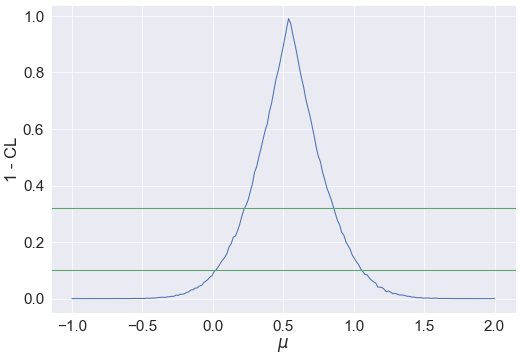

In [38]:
plt.figure(figsize=(12, 8), dpi=50)

plt.plot(mus,1 - np.array(cls))

plt.xlabel(r"$\mu$")
plt.ylabel(r"1 - CL")
plt.axhline(1 - 0.9, c="g")
plt.axhline(1 - 0.68, c="g")

plt.show()

In [39]:
def calculate_cl_hat_sigma_from_likelihood_ratios(mu, sigma, X, boot=10000):
    X_toy = norm.rvs(size=(len(X), boot), loc=mu, scale=sigma)

    toy_likelihood = chi2.logpdf((len(X) - 1) * (X_toy.std(axis=0)**2) / sigma**2, df=len(X) - 1)
    true_likelihood = chi2.logpdf((len(X) - 1) * (X.std() **2) / sigma**2, df=len(X) - 1)
    cl = (toy_likelihood >= true_likelihood).mean()
    return cl

In [40]:
mu = 0.2
sigmas = np.linspace(0.01, 4, 200)

cls = []
for sigma in tqdm(sigmas):
    cl = calculate_cl_hat_sigma_from_likelihood_ratios(mu=mu, sigma=sigma, X=X)
    cls.append(cl)

100%|██████████| 200/200 [00:00<00:00, 406.63it/s]


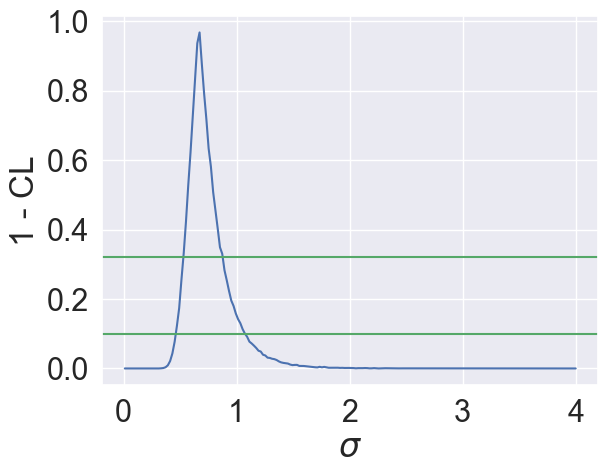

In [41]:
plt.plot(sigmas, 1 - np.array(cls))

plt.xlabel(r"$\sigma$")
plt.ylabel(r"1 - CL")
plt.axhline(1 - 0.9, c="g")
plt.axhline(1 - 0.68, c="g")
plt.show()

In [64]:
def calculate_cl_from_likelihood_ratios(mu, sigma, X, boot=10000):
    X_toy = norm.rvs(size=(len(X), boot), loc=mu, scale=sigma)

    toy_likelihood_mu = norm.logpdf(X_toy.mean(axis=0), loc=mu, scale=sigma / np.sqrt(len(X)))
    true_likelihood_mu = norm.logpdf(X.mean(), loc=mu, scale=sigma / np.sqrt(len(X))) 
    
    toy_likelihood_sigma = chi2.logpdf((len(X) - 1) * (X_toy.std(axis=0, ddof = 1)**2) / sigma**2, df=len(X) - 1)
    true_likelihood_sigma = chi2.logpdf((len(X) - 1) * (X.std(ddof= 1)**2) / sigma**2, df=len(X) - 1) 
    
    cl = (toy_likelihood_mu + toy_likelihood_sigma >= true_likelihood_mu + true_likelihood_sigma).mean()

    return cl

In [65]:
from collections import defaultdict

mus = np.linspace(-5, 5, 100)
sigmas = np.linspace(0.1, 10, 100)
MUS, SIGMAS = np.meshgrid(mus, sigmas)

cls = []
for mu, sigma in tqdm(list(zip(MUS.reshape(-1), SIGMAS.reshape(-1)))):
    cl = calculate_cl_from_likelihood_ratios(mu, sigma, X, boot=5000)
    cls.append(cl)

100%|██████████| 10000/10000 [00:14<00:00, 672.70it/s]


In [66]:
CLS = np.array(cls).reshape(*MUS.shape)

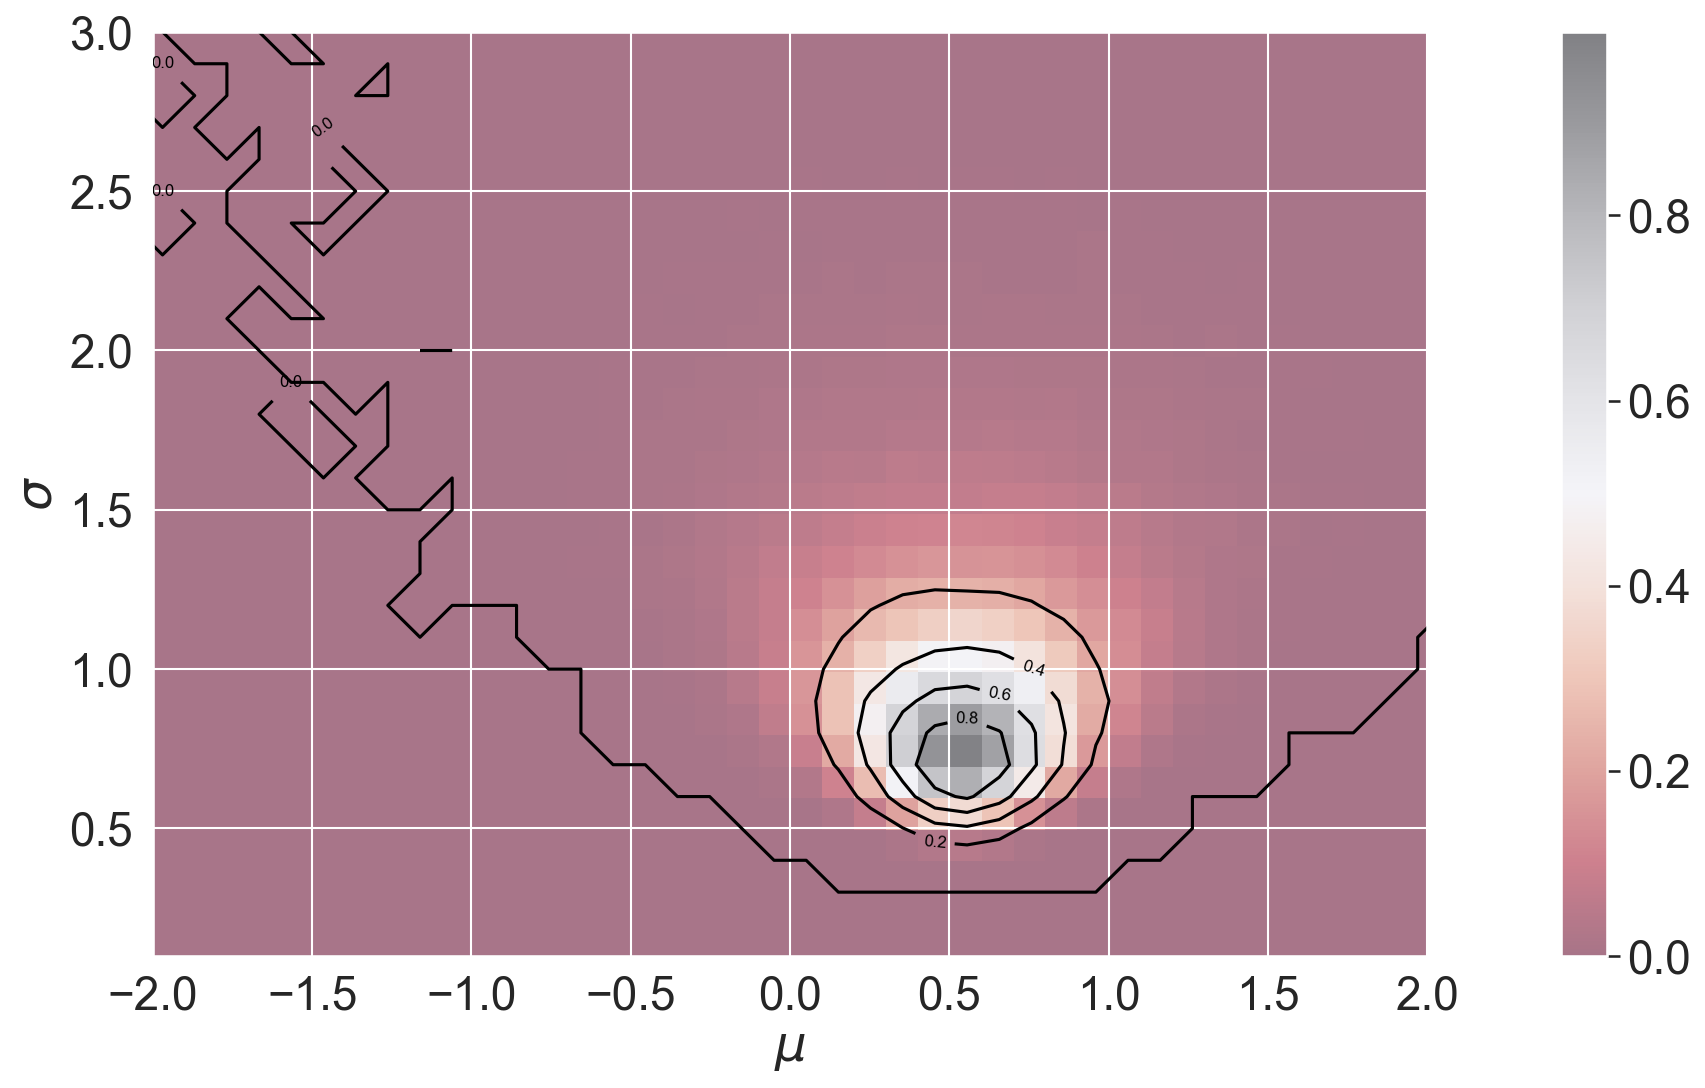

In [67]:
plt.figure(figsize=(23, 8), dpi=150)

contours = plt.contour(MUS, SIGMAS, 1 - CLS, 5, colors='black')
plt.clabel(contours, inline=True, fontsize=8)

plt.imshow(
    1- CLS, extent=[-5, 5, 0.1, 10],
    origin='lower',
    cmap='RdGy', alpha=0.5
)

plt.xlim(-2, 2)
plt.ylim(0.1, 3.0)   # <-- this shortens the y-axis view

plt.xlabel(r"$\mu$")
plt.ylabel(r"$\sigma$")
plt.colorbar()
plt.show()


For details on how to construct **1D intervals** using the Neyman construction, I’m sending you on a nice journey through the following paper :)

**Giovanni Punzi.** “Ordering Algorithms and Confidence Intervals in the Presence of Nuisance Parameters.”  
In: *Statistical Problems in Particle Physics, Astrophysics and Cosmology (PHYSTAT05 Proceedings)*,  
eds. Louis Lyons and Müge Karagöz Ünel. Imperial College Press, 2006, pp. 88–92.
